# Download and Classify Images with Confidence Threshold

This notebook:
1. Downloads images from URLs in metadata CSV
2. Handles missing/unavailable images gracefully
3. Classifies images as Urban/Natural using ResNet
4. Filters by confidence threshold (only keeps high-confidence predictions)
5. Excludes Indoor predictions
6. Saves filtered dataset for training

## 1. Setup and Imports

In [1]:
import os
import sys
from pathlib import Path

# Setup paths
current = Path.cwd()
src_path = current / "src" if (current / "src").exists() else current.parent
sys.path.insert(0, str(src_path))

from utils.paths import find_project_root

project_root = find_project_root(src_path)
data_dir = project_root / "data"
os.chdir(project_root)
sys.path.insert(0, str(project_root / "src"))
print("Project Root:", project_root)

Project Root: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS


In [ ]:
import requests
import pandas as pd
from PIL import Image
from tqdm import tqdm
from io import BytesIO
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

## 2. Configuration

In [3]:
# ========== CONFIGURATION ==========

# Input/Output paths
INPUT_METADATA = project_root / "data" / "metadata" / "original-datasets" / "metadata_mp16_for_osvmini.csv"
OUTPUT_DIR = project_root / "data" / "raw" / "mp16_images"
OUTPUT_CSV = project_root / "data" / "metadata" / "places-classification" / "mp16_with_predictions.csv"

# Classification threshold (only keep predictions with confidence >= this value)
CONFIDENCE_THRESHOLD = 0.70  # Adjust this value (0.0 to 1.0)

# Download settings
MAX_RETRIES = 2  # Reduced from 3 for speed
TIMEOUT = 5  # Reduced from 10 for speed
BATCH_SIZE = 64  # Increased for better GPU utilization
NUM_DOWNLOAD_THREADS = 16  # Parallel downloads

# Testing mode - set to a small number to test (e.g., 100), or None to process all
TEST_LIMIT = None  # Set to 100 or 500 to test first, then set to None for full run

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input CSV: {INPUT_METADATA}")
print(f"Output Directory: {OUTPUT_DIR}")
print(f"Output CSV: {OUTPUT_CSV}")
print(f"Confidence Threshold: {CONFIDENCE_THRESHOLD}")
print(f"Parallel Downloads: {NUM_DOWNLOAD_THREADS} threads")
print(f"Batch Size: {BATCH_SIZE}")
if TEST_LIMIT:
    print(f"⚠️  TEST MODE: Processing only first {TEST_LIMIT} images")

Input CSV: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\metadata\original-datasets\metadata_mp16_for_osvmini.csv
Output Directory: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\raw\mp16_images
Output CSV: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\metadata\places-classification\mp16_with_predictions.csv
Confidence Threshold: 0.7
Parallel Downloads: 16 threads
Batch Size: 64


## 4. Image Download with Error Handling

In [6]:
def download_image_from_url(url, max_retries=MAX_RETRIES, timeout=TIMEOUT):
    """Download image from URL with retry logic.
    
    Returns:
        PIL.Image or None if download fails
    """
    for attempt in range(max_retries):
        try:
            response = requests.get(url, timeout=timeout, stream=True)
            response.raise_for_status()
            
            # Load image from bytes
            img = Image.open(BytesIO(response.content)).convert('RGB')
            return img
            
        except requests.exceptions.Timeout:
            if attempt < max_retries - 1:
                time.sleep(0.5)  # Reduced wait time
                continue
        except requests.exceptions.RequestException:
            return None
        except Exception:
            return None
    
    return None  # All retries failed


def download_single_image(row_tuple):
    """Helper function for parallel downloads.
    
    Args:
        row_tuple: (index, row) from DataFrame.iterrows()
    
    Returns:
        dict with 'idx', 'row', 'img', and 'status'
    """
    idx, row = row_tuple
    img = download_image_from_url(row['url'])
    
    return {
        'idx': idx,
        'row': row,
        'img': img,
        'status': 'success' if img is not None else 'failed'
    }

## 5. Main Processing Pipeline

In [ ]:
# Initialize classifier
from src.models.classifier import SceneClassifierWithConfidence


print("Initializing classifier...")
classifier = SceneClassifierWithConfidence()
print("Classifier ready!")
print()

Initializing classifier...
Using Device: cuda
Loading scene hierarchy...
Loading resnet50...
Classifier ready!



In [8]:
# Load metadata
print(f"\nLoading metadata from {INPUT_METADATA}...")
df_metadata = pd.read_csv(INPUT_METADATA)
print(f"Found {len(df_metadata)} images to process")
print(f"Columns: {df_metadata.columns.tolist()}")
df_metadata.head()


Loading metadata from F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\metadata\original-datasets\metadata_mp16_for_osvmini.csv...
Found 167395 images to process
Columns: ['id', 'latitude', 'longitude', 'h_raw', 'h', 'url']


,id,latitude,longitude,h_raw,h,url
0,a6/e7/2734062435.jpg,42.838716,-124.565391,"['N4743600860', 'W481423199', 'R1837110', 'R16...","['R1837110', 'R165476', 'R148838']",http://farm4.staticflickr.com/3243/2734062435_...
1,62/2b/2760179641.jpg,42.838716,-124.565391,"['N4743600860', 'W481423199', 'R1837110', 'R16...","['R1837110', 'R165476', 'R148838']",http://farm4.staticflickr.com/3290/2760179641_...
2,a2/a5/6505195149.jpg,42.836825,-124.563365,"['N5296027503', 'W481423199', 'R1837110', 'R16...","['R1837110', 'R165476', 'R148838']",http://farm8.staticflickr.com/7019/6505195149_...
3,c9/4c/9399802156.jpg,42.836450,-124.563331,"['N5296027503', 'W481423199', 'R1837110', 'R16...","['R1837110', 'R165476', 'R148838']",http://farm4.staticflickr.com/3796/9399802156_...
4,dc/cf/7950872250.jpg,42.836403,-124.563149,"['N5296027503', 'W481423199', 'R1837110', 'R16...","['R1837110', 'R165476', 'R148838']",http://farm9.staticflickr.com/8445/7950872250_...


In [12]:
# ============ STEP 1: PARALLEL DOWNLOAD ALL IMAGES ============
print("="*60)
print("STEP 1: PARALLEL DOWNLOAD ALL IMAGES")
print("="*60)

failed_downloads = []

# Apply test limit if set
df_to_process = df_metadata.head(TEST_LIMIT) if TEST_LIMIT else df_metadata

# Build list of existing files (recursively)
existing_files = set()
for p in OUTPUT_DIR.glob("**/*"):
    if p.is_file():
        # Store both the filename and the relative path from OUTPUT_DIR
        existing_files.add(p.name)
        rel_path = p.relative_to(OUTPUT_DIR)
        existing_files.add(str(rel_path))
        existing_files.add(str(rel_path).replace('\\', '/'))  # Handle Windows paths

# Debug: Show sample of existing files
if existing_files:
    print(f"Found {len(existing_files)} existing file references")
    print(f"Sample existing files: {list(existing_files)[:5]}")
else:
    print("No existing files found in OUTPUT_DIR")

# Debug: Show sample IDs from metadata
print(f"Sample IDs from metadata: {df_to_process['id'].head(5).tolist()}")

def _is_already_downloaded(image_id: str) -> bool:
    """Check if image already exists in various formats."""
    # Try exact match
    if image_id in existing_files:
        return True
    
    # Try with/without .jpg extension
    if image_id.endswith(".jpg"):
        base_id = image_id.replace(".jpg", "")
        if base_id in existing_files:
            return True
    else:
        if f"{image_id}.jpg" in existing_files:
            return True
    
    # Try with Windows/Unix path separators
    id_unix = image_id.replace('\\', '/')
    id_win = image_id.replace('/', '\\')
    if id_unix in existing_files or id_win in existing_files:
        return True
    
    return False

# Separate already-downloaded from need-to-download
df_already_downloaded = df_to_process[df_to_process["id"].astype(str).apply(_is_already_downloaded)]
df_needs_download = df_to_process[~df_to_process["id"].astype(str).apply(_is_already_downloaded)]

print(f"\nAlready downloaded: {len(df_already_downloaded)} images")
print(f"Need to download: {len(df_needs_download)} images")
print(f"Downloading with {NUM_DOWNLOAD_THREADS} threads...\n")

# Storage for downloaded images and metadata
downloaded_data = []  # List of (row, img_path) tuples

# Add already-downloaded images to the list
for _, row in df_already_downloaded.iterrows():
    # Try to find the actual file path
    img_id = str(row['id'])
    
    # Try different path variations
    possible_paths = [
        OUTPUT_DIR / img_id,
        OUTPUT_DIR / f"{img_id}.jpg",
        OUTPUT_DIR / img_id.replace('.jpg', ''),
    ]
    
    # Also try as direct filename in case it's not in a subdirectory
    if not img_id.endswith('.jpg'):
        possible_paths.append(OUTPUT_DIR / f"{img_id}.jpg")
    
    img_path = None
    for path in possible_paths:
        if path.exists() and path.is_file():
            img_path = path
            break
    
    if img_path:
        downloaded_data.append({
            'row': row,
            'img_path': img_path
        })

print(f"Added {len(downloaded_data)} already-downloaded images to processing queue")

# Download remaining images with progress bar
if len(df_needs_download) > 0:
    with ThreadPoolExecutor(max_workers=NUM_DOWNLOAD_THREADS) as executor:
        future_to_row = {
            executor.submit(download_single_image, row_tuple): row_tuple 
            for row_tuple in df_needs_download.iterrows()
        }
        
        # Use tqdm to show progress
        with tqdm(total=len(future_to_row), desc="Downloading", unit="img") as pbar:
            for future in as_completed(future_to_row):
                try:
                    result = future.result()
                    
                    if result['status'] == 'failed':
                        failed_downloads.append({
                            'id': result['row']['id'],
                            'url': result['row']['url'],
                            'reason': 'download_failed'
                        })
                    else:
                        # Save image to disk
                        img_filename = result['row']['id']
                        if not img_filename.endswith('.jpg'):
                            img_filename = f"{img_filename}.jpg"
                        img_path = OUTPUT_DIR / img_filename
                        img_path.parent.mkdir(parents=True, exist_ok=True)
                        result['img'].save(img_path)
                        
                        # Store reference to downloaded image
                        downloaded_data.append({
                            'row': result['row'],
                            'img_path': img_path
                        })
                except Exception as e:
                    pass
                
                pbar.update(1)

print(f"\n✓ Total ready for classification: {len(downloaded_data)} images")
print(f"  - Already existed: {len(df_already_downloaded)}")
print(f"  - Newly downloaded: {len(downloaded_data) - len(df_already_downloaded)}")
print(f"✗ Failed downloads: {len(failed_downloads)} images\n")


STEP 1: PARALLEL DOWNLOAD ALL IMAGES
Found 436560 existing file references
Sample existing files: ['0c\\ff\\1351419886.jpg', 'cb\\df\\5186546136.jpg', '24\\58\\390593211.jpg', '7974521895.jpg', '84\\bc\\2507261865.jpg']
Sample IDs from metadata: ['a6/e7/2734062435.jpg', '62/2b/2760179641.jpg', 'a2/a5/6505195149.jpg', 'c9/4c/9399802156.jpg', 'dc/cf/7950872250.jpg']

Already downloaded: 145520 images
Need to download: 21875 images

Added 145520 already-downloaded images to processing queue


Downloading: 100%|██████████| 21875/21875 [04:21<00:00, 83.51img/s] 


✓ Total ready for classification: 145688 images
  - Already existed: 145520
  - Newly downloaded: 168
✗ Failed downloads: 21707 images



In [11]:
len(downloaded_data)

37634

In [13]:
# ============ STEP 2: CLASSIFY ALL DOWNLOADED IMAGES ============
print("="*60)
print("STEP 2: CLASSIFY ALL DOWNLOADED IMAGES")
print("="*60)

results = []
low_confidence = []
indoor_rejected = []

print(f"Classifying {len(downloaded_data)} images in batches of {BATCH_SIZE}...\n")

# Process downloaded images in GPU-friendly batches
for batch_start in tqdm(range(0, len(downloaded_data), BATCH_SIZE), desc="Classifying", unit="batch"):
    batch_end = min(batch_start + BATCH_SIZE, len(downloaded_data))
    batch_items = downloaded_data[batch_start:batch_end]
    
    # Load images from disk
    batch_images = []
    batch_rows = []
    
    for item in batch_items:
        try:
            img = Image.open(item['img_path']).convert('RGB')
            batch_images.append(img)
            batch_rows.append(item['row'])
        except Exception as e:
            # Skip corrupted files
            continue
    
    if len(batch_images) == 0:
        continue
    
    # Classify batch
    labels, confidences = classifier.process_images(batch_images)
    
    # Filter and record results
    for img, row, label_int, conf in zip(batch_images, batch_rows, labels, confidences):
        label_str = classifier.label_int_to_str(label_int)
        
        # Filter: Skip Indoor
        if label_str == 'Indoor':
            indoor_rejected.append({
                'id': row['id'],
                'predicted_label': label_str,
                'confidence': conf
            })
            continue
        
        # Filter: Check confidence threshold
        if conf < CONFIDENCE_THRESHOLD:
            low_confidence.append({
                'id': row['id'],
                'predicted_label': label_str,
                'confidence': conf
            })
            continue
        
        # PASSED ALL FILTERS - Record result
        results.append({
            'id': row['id'].replace('.jpg', ''),
            'latitude': row['latitude'],
            'longitude': row['longitude'],
            'predicted_label': label_str,
            'confidence': conf,
            'url': row['url']
        })

print("\n" + "="*60)
print("PROCESSING COMPLETE")
print("="*60)

STEP 2: CLASSIFY ALL DOWNLOADED IMAGES
Classifying 145688 images in batches of 64...



Classifying: 100%|██████████| 2277/2277 [17:51<00:00,  2.12batch/s]


PROCESSING COMPLETE


## 6. Results Summary

In [14]:
# Create results DataFrame
df_results = pd.DataFrame(results)

# Print summary statistics
print(f"\nTotal images in metadata: {len(df_metadata)}")
print(f"Failed downloads: {len(failed_downloads)}")
print(f"Rejected (Indoor): {len(indoor_rejected)}")
print(f"Rejected (Low confidence): {len(low_confidence)}")
print(f"Successfully added to dataset: {len(df_results)}")
print(f"\nSuccess rate: {len(df_results)/len(df_metadata)*100:.1f}%")

if len(df_results) > 0:
    print(f"\nLabel distribution:")
    print(df_results['predicted_label'].value_counts())
    print(f"\nConfidence statistics:")
    print(df_results['confidence'].describe())


Total images in metadata: 167395
Failed downloads: 21707
Rejected (Indoor): 62231
Rejected (Low confidence): 25211
Successfully added to dataset: 58246

Success rate: 34.8%

Label distribution:
predicted_label
Urban      35357
Natural    22889
Name: count, dtype: int64

Confidence statistics:
count    58246.000000
mean         0.902419
std          0.089199
min          0.700012
25%          0.835121
50%          0.931772
75%          0.981176
max          1.000000
Name: confidence, dtype: float64


In [15]:
# Save results
if len(df_results) > 0:
    OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    df_results.to_csv(OUTPUT_CSV, index=False)
    print(f"\nSaved results to: {OUTPUT_CSV}")
else:
    print("\nNo images passed the filters. No CSV created.")


Saved results to: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\metadata\places-classification\mp16_with_predictions.csv


In [16]:
# Save rejection logs (optional)
if len(failed_downloads) > 0:
    failed_df = pd.DataFrame(failed_downloads)
    failed_path = OUTPUT_CSV.parent / "mp16_failed_downloads.csv"
    failed_df.to_csv(failed_path, index=False)
    print(f"Saved failed downloads log to: {failed_path}")

if len(low_confidence) > 0:
    low_conf_df = pd.DataFrame(low_confidence)
    low_conf_path = OUTPUT_CSV.parent / "mp16_low_confidence.csv"
    low_conf_df.to_csv(low_conf_path, index=False)
    print(f"Saved low confidence log to: {low_conf_path}")

if len(indoor_rejected) > 0:
    indoor_df = pd.DataFrame(indoor_rejected)
    indoor_path = OUTPUT_CSV.parent / "mp16_indoor_rejected.csv"
    indoor_df.to_csv(indoor_path, index=False)
    print(f"Saved indoor rejections log to: {indoor_path}")

Saved failed downloads log to: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\metadata\places-classification\mp16_failed_downloads.csv
Saved low confidence log to: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\metadata\places-classification\mp16_low_confidence.csv
Saved indoor rejections log to: F:\InfTech\Prodotti\Python\GeoLocGit\GeoLoc-CVCS\data\metadata\places-classification\mp16_indoor_rejected.csv


## 7. Visualize Sample Results (Optional)

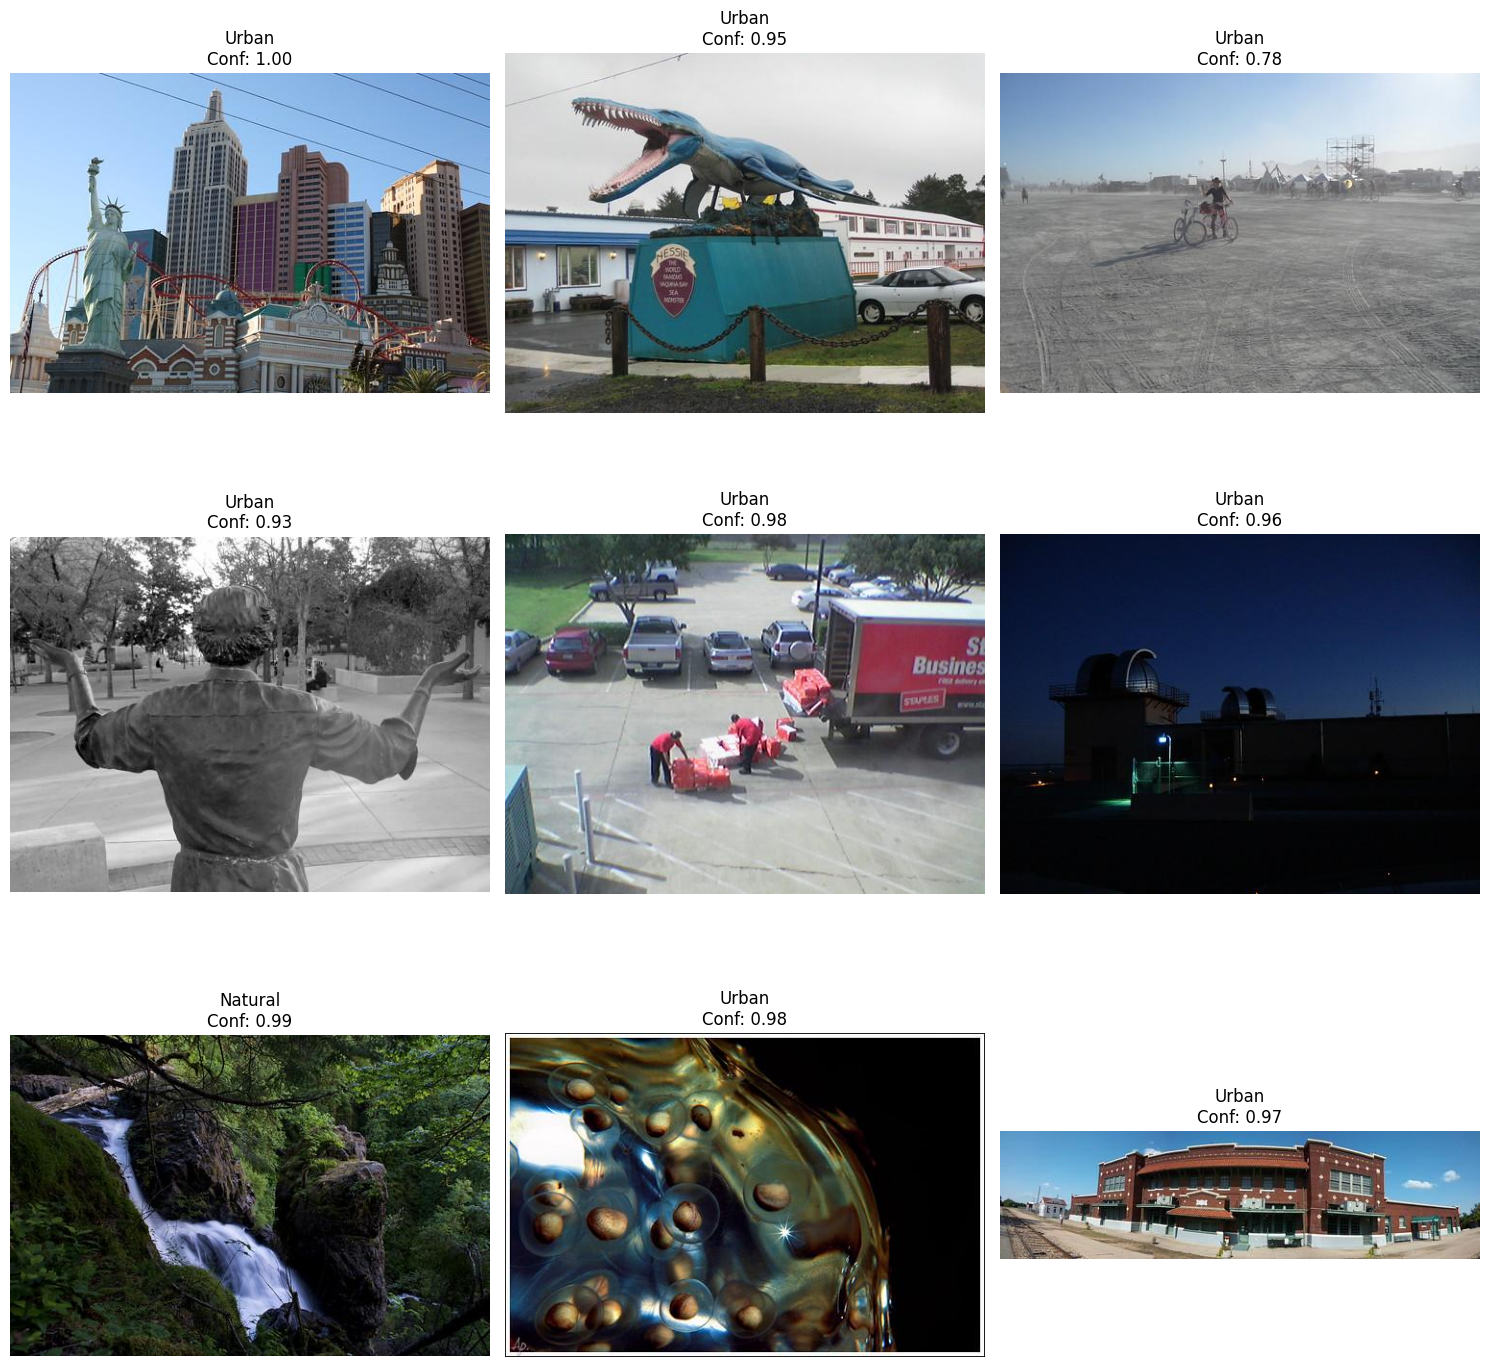

In [17]:
import matplotlib.pyplot as plt

if len(df_results) > 0:
    # Show some sample images
    n_samples = min(9, len(df_results))
    sample_results = df_results.sample(n=n_samples)
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()
    
    for idx, (_, row) in enumerate(sample_results.iterrows()):
        if idx >= 9:
            break
        
        img_path = OUTPUT_DIR / f"{row['id']}.jpg"
        if img_path.exists():
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(f"{row['predicted_label']}\nConf: {row['confidence']:.2f}")
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No images to display.")